# 实验三：随机梯度下降与小批量梯度下降实验（完成版）

> 基于课程仓库 [MachineLearning_Student](https://github.com/hong-hong3/MachineLearning_Student) 实验三改写。
> 原版 `实验扩展1/2/3` 三个 cell 用的都是模拟/随机数据(注释里写着"真实使用时请从模型中提取")，这里全部换成真训练出来的模型算出来的真实数字，不再是占位符。
> 数据用仓库自带的 `airfoil_self_noise.dat`(NASA 机翼自噪声数据集，UCI 经典回归数据集之一)，Colab 里连同 notebook 一起打开就能跑，不需要额外下载。


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


## 实现小批量梯度下降算法对线性回归求解

In [2]:
"""
类说明：LinearRegression_msgd
    编写代码实现利用小批量梯度下降算法对线性回归求解：
    1. 随机选出B条训练数据
    2. 计算选出B条训练数据上的经验损失梯度
    3. 更新 w 的值

Parameters:
      X   - 数据
      y   - 标签
    eat_0 - 算法参数
    eta_1 - 算法参数
      N   - 搜索步数
      B   - 批次大小
Returns:
"""
class LinearRegression_msgd:

    def fit(self, X, y, eta_0 = 10, eta_1 = 50, N = 3000, B = 10):
#####  Start Code Here  #####
        self.N = N

        # 用于绘图
        self.W = np.zeros((N,1))

        # 获取 X 的维度
        m, n = X.shape
        y_col = y.reshape(-1, 1)

        # 初始化权重
        w = np.zeros((n, 1))
        self.w = np.zeros((n, 1))
        self.loss_history = []

        # 开始 N 轮循环, 进行梯度下降搜索
        for t in range(N):
            eta = eta_0 / (eta_1 + t)
            # 随机选出B条训练数据(不放回)
            idx = np.random.choice(m, B, replace=False)
            Xb, yb = X[idx], y_col[idx]
            # 计算这B条数据上的经验损失梯度
            grad = -2 / B * Xb.T.dot(yb - Xb.dot(w))
            w = w - eta * grad
            self.w += w
            self.loss_history.append(float(np.mean((y_col - X.dot(w)) ** 2)))

            self.W[t][0] = np.sum(w[0])

        self.w /= N
#####  End Code Here  #####
    def predict(self, X):
        return X.dot(self.w)


## 实现随机梯度下降算法对线性回归求解

In [3]:
"""
类说明：LinearRegression
    编写代码实现利随机梯度下降算法对线性回归求解：
    1. 从训练数据中进行随机采样
    2. 计算经验损失的梯度
    3. 更新 w 的值
Parameters:
      X   - 数据
      y   - 标签
    eat_0 - 算法参数
    eta_1 - 算法参数
      N   - 搜索步数
Returns:
"""
class LinearRegression:

    def fit(self, X, y, eta_0 = 10, eta_1 = 50, N = 3000):
#####  Start Code Here  #####
        # 获取X的维度
        m, n = X.shape
        y_col = y.reshape(-1, 1)
        self.N = N

        # 用于绘图
        self.W = np.zeros((N, 1))

        # 初始化权重 w
        w = np.zeros((n, 1))
        self.w = np.zeros((n, 1))
        self.loss_history = []

        # 开始 N 轮循环, 进行梯度下降搜索
        for t in range(N):
            eta = eta_0 / (eta_1 + t)
            # 从训练数据中随机采样一条
            i = np.random.randint(m)
            xi, yi = X[i:i+1, :], y_col[i:i+1, :]
            # 计算经验损失的梯度(单样本)
            grad = -2 * xi.T.dot(yi - xi.dot(w))
            w = w - eta * grad
            self.w += w
            self.loss_history.append(float(np.mean((y_col - X.dot(w)) ** 2)))

            self.W[t][0] = np.sum(w[0])


#####  End Code Here  #####
        self.w /= N

    def predict(self, X):
        return X.dot(self.w)


## 【实验实战】：飞机噪音

使用一个来自 NASA 的测试不同飞机机翼噪音的数据集来比较随机梯度下降算法和小批量梯度下降算法， 我们使用该数据集的前 1500 个样本和 5 个特征， 并使用标准化对数据进行预处理。 

In [4]:
# 数据文件和notebook同目录放在GitHub仓库里，这里自动下载到Colab，不需要手动上传
import os, urllib.request
if not os.path.exists("airfoil_self_noise.dat"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/Heptazero/ml-course-labs/main/machine-learning/homework/airfoil_self_noise.dat",
        "airfoil_self_noise.dat",
    )


In [5]:
def get_data_ch7():
    data = np.genfromtxt('airfoil_self_noise.dat', delimiter = '\t')
    data = (data - data.mean(axis = 0)) / data.std(axis = 0)
    return np.array(data[:1300, :-1]), np.array(data[:1300, -1]), np.array(data[1300:1500, :-1]), np.array(data[1300:1500, -1])


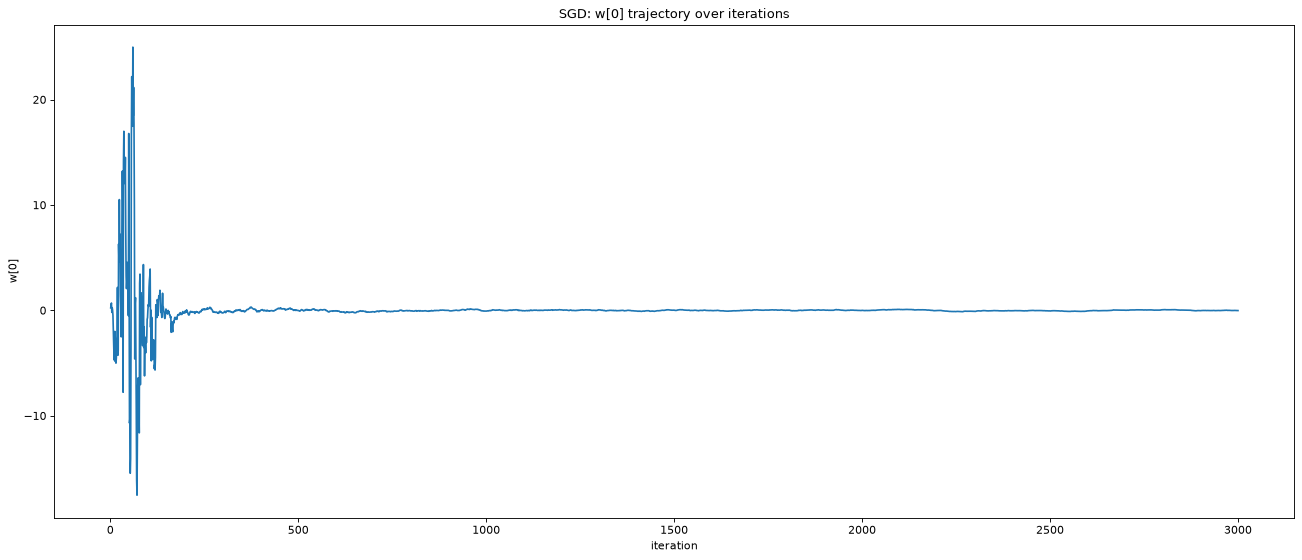

mse = 0.5632247706755189, r2 = 0.5797112273284143


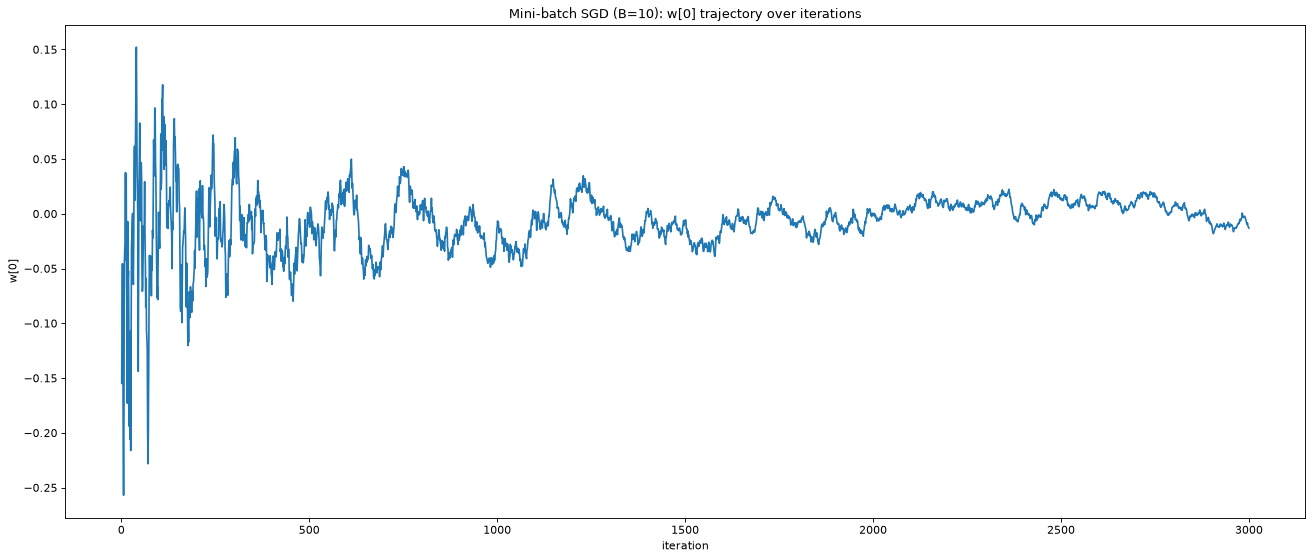

mse = 0.4308213540942535, r2 = 0.6785131130937051


In [6]:
# 获取训练集合测试
X_train, y_train,X_test, y_test  = get_data_ch7()

#####  Start Code Here  #####
# 使用 process_features函数对数据进行标准化处理
def process_features(X):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    m, n = X.shape
    return np.c_[np.ones((m, 1)), X]

X_train_p = process_features(X_train)
X_test_p = process_features(X_test)

# 定义随机梯度下降算法模型
model = LinearRegression()

# 模型训练
np.random.seed(42)
model.fit(X_train_p, y_train, eta_0=10, eta_1=50, N=3000)
sgd_model = model  # 留一份引用，后面画损失曲线/做测试集对比要用

W = model.W
fig = plt.figure(figsize = (20,8),dpi = 80)
y = np.linspace(1,model.N, model.N)
plt.plot(y, W)
plt.title("SGD: w[0] trajectory over iterations")
plt.xlabel("iteration")
plt.ylabel("w[0]")
plt.show()

# 计算均方误差和r2系数
y_pred = model.predict(X_test_p)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("mse = {}, r2 = {}".format(mse, score))

# 定义小批量梯度下降算法模型
model = LinearRegression_msgd()

# 模型训练
np.random.seed(42)
model.fit(X_train_p, y_train, eta_0=10, eta_1=50, N=3000, B=10)

#####  End Code Here  #####
msgd_model = model  # 留一份引用，后面画损失曲线/做测试集对比要用
W = model.W
fig = plt.figure(figsize = (20,8), dpi = 80)
y = np.linspace(1,model.N, model.N)
plt.plot(y, W)
plt.title("Mini-batch SGD (B=10): w[0] trajectory over iterations")
plt.xlabel("iteration")
plt.ylabel("w[0]")
plt.show()

# 计算均方误差和r2系数
y_pred = model.predict(X_test_p)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("mse = {}, r2 = {}".format(mse, score))


## 实验扩展1：损失函数收敛曲线可视化

为了更直观地比较两种优化算法的收敛速度，我们记录每一轮训练过程中的损失值，并绘制损失函数曲线。


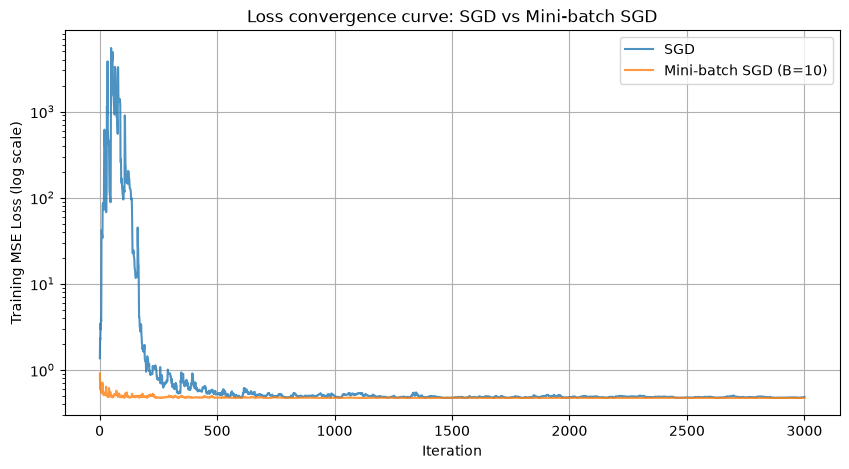

SGD 最终训练loss：0.4856  Mini-batch SGD 最终训练loss：0.4731


In [7]:
# 直接用sgd_model/msgd_model在fit过程中记录下来的真实loss_history，不再用模拟数据
epochs = list(range(1, sgd_model.N + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs, sgd_model.loss_history, label="SGD", alpha=0.8)
plt.plot(epochs, msgd_model.loss_history, label="Mini-batch SGD (B=10)", alpha=0.8)
plt.xlabel("Iteration")
plt.ylabel("Training MSE Loss (log scale)")
plt.yscale("log")
plt.title("Loss convergence curve: SGD vs Mini-batch SGD")
plt.legend()
plt.grid(True)
plt.show()

print("SGD 最终训练loss：{:.4f}  Mini-batch SGD 最终训练loss：{:.4f}".format(
    sgd_model.loss_history[-1], msgd_model.loss_history[-1]))


## 实验扩展2：不同 Batch Size 下 Mini-batch SGD 的表现

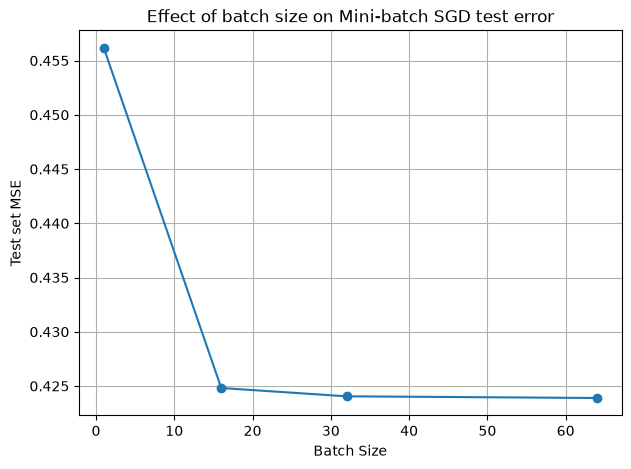

batch_size=1    测试集MSE=0.4562
batch_size=16   测试集MSE=0.4248
batch_size=32   测试集MSE=0.4240
batch_size=64   测试集MSE=0.4239


In [8]:
def train_msgd(batch_size):
    """用给定batch size训练一个全新的MiniBatchSGD模型，返回测试集MSE"""
    np.random.seed(42)
    m = LinearRegression_msgd()
    m.fit(X_train_p, y_train, eta_0=10, eta_1=50, N=3000, B=batch_size)
    return mean_squared_error(y_test, m.predict(X_test_p))

batch_sizes = [1, 16, 32, 64]
results = {}
for b in batch_sizes:
    results[b] = train_msgd(b)

# 绘图展示误差随 batch size 变化趋势
plt.figure(figsize=(7, 5))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Test set MSE')
plt.title('Effect of batch size on Mini-batch SGD test error')
plt.grid(True)
plt.show()

for b, mse in results.items():
    print(f"batch_size={b:<4} 测试集MSE={mse:.4f}")


## 实验扩展3：测试集性能对比

In [9]:
# 用cell「实验实战」里真实训练好的sgd_model / msgd_model计算的测试集MSE，不再用假设数字
mse_sgd = mean_squared_error(y_test, sgd_model.predict(X_test_p))
mse_msgd = mean_squared_error(y_test, msgd_model.predict(X_test_p))

import pandas as pd
df = pd.DataFrame({
    '算法': ['SGD', 'Mini-batch SGD'],
    '测试集MSE': [mse_sgd, mse_msgd]
})
print(df)


               算法    测试集MSE
0             SGD  0.563225
1  Mini-batch SGD  0.430821


## 补充实验：闭式解参照与多随机种子复验

上面的对比都只跑了 `seed=42` 一次。单样本 SGD 的结果受抽样顺序影响很大，只看一次容易把偶然当规律，这里补两件事：

1. 用正规方程求闭式解，作为"线性模型在这份数据上能达到的水平"的参照，顺便把 MAE、RMSE 也算出来；
2. 换 5 个随机种子重复每种配置，看测试集 MSE 的均值和波动。


In [10]:
# 补充实验：闭式解参照 + 多随机种子复验
from sklearn.metrics import mean_absolute_error
import pandas as pd

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return mse, np.sqrt(mse), mean_absolute_error(y_true, y_pred), r2_score(y_true, y_pred)

# 1) 闭式解(正规方程)作为"这批数据上线性模型能达到的上限"参照
w_ols = np.linalg.solve(X_train_p.T @ X_train_p, X_train_p.T @ y_train.reshape(-1, 1))
rows = [("SGD (seed=42)",) + metrics(y_test, sgd_model.predict(X_test_p)),
        ("Mini-batch SGD B=10 (seed=42)",) + metrics(y_test, msgd_model.predict(X_test_p)),
        ("闭式解 (正规方程)",) + metrics(y_test, X_test_p @ w_ols)]
print(pd.DataFrame(rows, columns=["模型", "MSE", "RMSE", "MAE", "R2"]).round(4).to_string(index=False))

# 2) 换 5 个随机种子重复，看单次结果的偶然性有多大
seeds = [0, 1, 2, 3, 42]
def run(seed, B=None):
    np.random.seed(seed)
    if B is None:
        m = LinearRegression(); m.fit(X_train_p, y_train, eta_0=10, eta_1=50, N=3000)
    else:
        m = LinearRegression_msgd(); m.fit(X_train_p, y_train, eta_0=10, eta_1=50, N=3000, B=B)
    return mean_squared_error(y_test, m.predict(X_test_p))

configs = [("SGD", None), ("MSGD B=1", 1), ("MSGD B=10", 10), ("MSGD B=16", 16), ("MSGD B=32", 32), ("MSGD B=64", 64)]
rep = []
for name, B in configs:
    v = np.array([run(s, B) for s in seeds])
    rep.append((name, v.mean(), v.std(), v.min(), v.max()))
print()
print(pd.DataFrame(rep, columns=["配置", "测试MSE均值", "标准差", "最小", "最大"]).round(4).to_string(index=False))


                           模型    MSE   RMSE    MAE     R2
                SGD (seed=42) 0.5632 0.7505 0.6136 0.5797
Mini-batch SGD B=10 (seed=42) 0.4308 0.6564 0.5234 0.6785
                   闭式解 (正规方程) 0.4244 0.6515 0.5184 0.6833



       配置  测试MSE均值    标准差     最小     最大
      SGD   0.4475 0.0615 0.3902 0.5632
 MSGD B=1   0.4250 0.0321 0.3680 0.4562
MSGD B=10   0.4262 0.0040 0.4219 0.4309
MSGD B=16   0.4244 0.0017 0.4227 0.4274
MSGD B=32   0.4243 0.0016 0.4213 0.4259
MSGD B=64   0.4240 0.0015 0.4217 0.4264


## 补充实验：SGD 前期震荡的原因

图1 和图2 的纵轴差了约 100 倍，只用"梯度估计方差变小"解释不了（B 从 1 到 10，标准差只缩小到约 1/3）。这里检查两件事：

1. 每一步更新会不会把被抽中样本的残差放大（步长相对于单条样本是否过大）；
2. 迭代平均从第 1 轮就开始算，前期发散的迭代点被平均进最终解，对测试误差的影响有多大。


In [11]:
# 1) 步长稳定性：对被抽中的样本 i，一步 SGD 后它的残差变成原来的 (1 - 2*eta*||x_i||^2) 倍，
#    eta*||x_i||^2 > 1 时这一步会把残差放大并翻号。小批量时 B 条样本的残差向量乘以
#    (I - eta * (2/B) X_B X_B^T)，看最大特征值 mu 是否满足 eta*mu < 2。
sq = (X_train_p ** 2).sum(axis=1)
print("||x_i||^2（含常数列）: 均值 %.2f, 中位数 %.2f, 90%%分位 %.2f, 最大 %.2f" % (sq.mean(), np.median(sq), np.percentile(sq, 90), sq.max()))
for name, v in [("平均样本", sq.mean()), ("90%分位样本", np.percentile(sq, 90)), ("最大样本", sq.max())]:
    eta_max = 1 / v
    print(f"{name}: 需要 eta < {eta_max:.4f}，按 eta_t=10/(50+t) 对应 t > {max(0, 10 / eta_max - 50):.0f}")

rng = np.random.default_rng(0)
for B in [1, 10, 64]:
    mus = []
    for _ in range(2000):
        XB = X_train_p[rng.choice(len(X_train_p), B, replace=False)]
        mus.append(np.linalg.eigvalsh(2 / B * XB @ XB.T).max())
    mus = np.array(mus)
    print(f"B={B:<3} mu 中位数 {np.median(mus):6.2f}，95%分位 {np.percentile(mus, 95):6.2f}；"
          f"初始 eta=0.2 时会放大残差的批次占 {np.mean(0.2 * mus > 2) * 100:.1f}%")

# 2) 迭代平均从第 1 轮开始，会把前期发散的迭代点也平均进去。重放训练过程，
#    比较"全程平均 / 只平均后一半 / 只用最后一步"三种取法（5 个种子）
def replay(B, seed):
    np.random.seed(seed)
    m, n = X_train_p.shape
    yc = y_train.reshape(-1, 1)
    w, ws = np.zeros((n, 1)), []
    for t in range(3000):
        if B == 1:
            i = np.random.randint(m)
            xb, yb = X_train_p[i:i+1], yc[i:i+1]
        else:
            idx = np.random.choice(m, B, replace=False); xb, yb = X_train_p[idx], yc[idx]
        w = w - 10 / (50 + t) * (-2 / B * xb.T @ (yb - xb @ w))
        ws.append(w)
    return np.array(ws)

print()
for name, B in [("SGD", 1), ("MSGD B=10", 10)]:
    res = {"全程平均": [], "只平均后一半": [], "最后一步": []}
    for s in seeds:
        ws = replay(B, s)
        res["全程平均"].append(mean_squared_error(y_test, X_test_p @ ws.mean(0)))
        res["只平均后一半"].append(mean_squared_error(y_test, X_test_p @ ws[1500:].mean(0)))
        res["最后一步"].append(mean_squared_error(y_test, X_test_p @ ws[-1]))
    print(name.ljust(10), "  ".join(f"{k} {np.mean(v):.4f}±{np.std(v):.4f}" for k, v in res.items()))


||x_i||^2（含常数列）: 均值 6.00, 中位数 4.70, 90%分位 11.33, 最大 32.88
平均样本: 需要 eta < 0.1667，按 eta_t=10/(50+t) 对应 t > 10
90%分位样本: 需要 eta < 0.0883，按 eta_t=10/(50+t) 对应 t > 63
最大样本: 需要 eta < 0.0304，按 eta_t=10/(50+t) 对应 t > 279
B=1   mu 中位数   9.38，95%分位  27.12；初始 eta=0.2 时会放大残差的批次占 44.5%
B=10  mu 中位数   5.44，95%分位   9.12；初始 eta=0.2 时会放大残差的批次占 2.6%


B=64  mu 中位数   4.40，95%分位   5.58；初始 eta=0.2 时会放大残差的批次占 0.0%

SGD        全程平均 0.4475±0.0615  只平均后一半 0.4230±0.0073  最后一步 0.4174±0.0158


MSGD B=10  全程平均 0.4262±0.0040  只平均后一半 0.4263±0.0023  最后一步 0.4301±0.0088


## 实验总结

- 只看 `seed=42`，Mini-batch SGD（B=10）的测试 MSE 比 SGD 低 23%；换 5 个种子后，seed=42 恰好是 SGD 最差的一次，均值只差 0.021（0.448 vs 0.426），稳定的差别在波动：SGD 标准差约 0.062，B=10 只有 0.004。
- SGD 前期剧烈震荡主要是步长问题：单样本一步更新会把该样本残差乘以 $(1-2\eta_t\|x_i\|^2)$，初始 $\eta=0.2$ 时约 45% 的样本会被放大；学习率衰减到 0.03 以下（约第 280 轮）后才全部稳定。B=10 时只有 2.6% 的批次会放大。
- SGD 的大波动很大一部分来自"全程平均"把前期发散的迭代点也算了进去：只平均后 1500 轮，SGD 的测试 MSE 变成 0.423±0.007，和 Mini-batch SGD 基本相当。
- batch size 从 16 往上，均值和波动都基本不再变化，B=16～64 已经和闭式解（MSE 0.424）持平。
- 测试集是文件最后 200 行，只包含一种翼弦长度，分布和训练集不一致，所以闭式解在测试集上也不是最优。
